In [1]:
import warnings
warnings.filterwarnings('ignore')

(Tutorial_Get_pi_pi_interactions)=
# Get pi-pi interactions

*Detecting explicit parallel and edge-to-face geometries between declared aromatic rings.*

Calculate a sparse analysis of aromatic ring pairs in each selected structure.
Chemical participants, geometric observations and energetic interpretations are distinct.
This experimental method takes explicit cutoffs; the example values illustrate a
reproducible definition and are not universal scientific recommendations.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for input arguments, errors and returned objects:
{func}`molsysmt.interactions.pi_pi.get_pi_pi_interactions`.
:::

## Basic usage

Let's show how this function works with an existing coordinate file and a
controlled two-ring ensemble. Coordinates alone cannot establish aromaticity.

In [2]:
import molsysmt as msm

In [3]:
demo = msm.systems['pentalanine']['traj_pentalanine.h5msm']
try:
    msm.interactions.pi_pi.get_pi_pi_interactions(
        demo, '.6 nm', '30 degrees', '.2 nm', '.02 nm', pbc=False)
except msm.StructuralInconsistencyError:
    print('Complete connectivity and explicit atom/bond aromatic flags are required.')

Complete connectivity and explicit atom/bond aromatic flags are required.


:::{note} Demo Systems Catalog
:class: dropdown

For bundled datasets see {ref}`Demo Systems <user-foundations-entrance-demo-systems>`.
:::

Two benzene rings provide deterministic planar participants. The native conversion
from SMILES needs the optional RDKit dependency. Here their relative placements
are controlled geometries, not simulated structures or evidence of binding.

In [4]:
import numpy as np
from molsysmt import pyunitwizard as puw

# RDKit supplies explicit aromatic atom/bond flags through this form conversion.
topology = msm.convert('smiles:c1ccccc1.c1ccccc1', to_form='molsysmt.Topology')
molsys = msm.convert(topology, to_form='molsysmt.MolSys')
phase = np.arange(6) * np.pi / 3
ring = .14 * np.column_stack((np.cos(phase), np.sin(phase), np.zeros(6)))
coordinates = np.array([
    np.concatenate((ring, ring + [0, 0, .35])),
    np.concatenate((ring, ring + [0, 0, 2.])),
    np.concatenate((ring, ring[:, [2, 1, 0]] + [0, 0, .4])),
])
molsys.structures.append(coordinates=puw.quantity(coordinates, 'nm'))

def calculate(source=molsys, **options):
    settings = dict(distance_threshold='.6 nm', angle_threshold='30 degrees',
                    offset_threshold='.2 nm', planarity_threshold='.02 nm', pbc=False)
    settings.update(options)
    return msm.interactions.pi_pi.get_pi_pi_interactions(source, **settings)

analysis = calculate()
print(analysis.n_interactions, analysis.occurrence_structures.tolist())
print(analysis.measure_units)
assert analysis.n_interactions == 2
assert not molsys.interactions

2 [0, 2]
{'distance': 'nm', 'plane_angle': 'radians', 'offset_a': 'nm', 'offset_b': 'nm', 'rms_deviation_a': 'nm', 'rms_deviation_b': 'nm', 'max_deviation_a': 'nm', 'max_deviation_b': 'nm'}


## Understanding the criterion

The arithmetic centroid and an unweighted least-squares normal describe each ring.
For observed centroid displacement $d$ and unit normal $n$, the lateral offset is
$\|d-(d\cdot n)n\|$. Plane angles are unoriented and lie between zero and 90 degrees.

| Class | Plane angle | Lateral offset |
| --- | --- | --- |
| Parallel | Deviation from zero within the angular cutoff | Both offsets within the cutoff |
| Edge to face | Deviation from 90 degrees within the angular cutoff | At least one offset within the cutoff |

Both classes require positive centroid distance within the distance cutoff and
both maximum orthogonal atom deviations within the planarity cutoff. The angular
cutoff must be below 45 degrees, keeping classes disjoint. Zero planarity or offset
cutoffs require numerical exactness; no absolute tolerance is inferred.

General chemistry and geometry tools let you inspect the participants independently.

In [5]:
rings = msm.physchem.get_aromatic_rings(molsys)
participants = [rings['atom_indices'][a:b] for a, b in zip(rings['atom_offsets'][:-1], rings['atom_offsets'][1:])]
planes = msm.structure.get_least_squares_plane(molsys, selection=participants)
print(rings['evidence'])
print(planes['max_deviation'])
print(analysis.evidence_labels)
print(analysis.occurrence_evidence.tolist())
assert analysis.occurrence_evidence.tolist() == [0, 1]

{'kind': 'chemical_states.is_aromatic', 'connectivity_completeness': 'complete', 'assume_complete_connectivity': False, 'chemical_state_provenance_index': None}
[[0.0 0.0] [0.0 0.0] [0.0 0.0]] nanometer
('declared_aromatic_parallel_geometry', 'declared_aromatic_edge_to_face_geometry')
[0, 1]


## Choosing geometric classes

Choose parallel, edge-to-face or both. Self, overlapping/fused and directly
covalently linked rings are excluded. Other intramolecular geometries remain eligible;
there is no residue, component, clash or energy filter.

In [6]:
parallel = calculate(geometry='parallel')
edge = calculate(geometry='edge_to_face')
print(parallel.occurrence_structures.tolist(), edge.occurrence_structures.tolist())
assert parallel.occurrence_structures.tolist() == [0]
assert edge.occurrence_structures.tolist() == [2]

[0] [2]


## Selecting structures

Indices are positions, not structure IDs. Repeated requested indices do not duplicate
observations. Evaluated empty frames remain distinguishable from frames not evaluated.

In [7]:
selected = calculate(structure_indices=[2, 0, 2])
empty = analysis.query(structure_indices=1).to_dict()
print(selected.evaluated_structure_indices.tolist())
print(empty['evaluated_structure_indices'].tolist(), empty['occurrence_indices'].tolist())
assert selected.evaluated_structure_indices.tolist() == [0, 2]
assert empty['evaluated_structure_indices'].tolist() == [1]

[0, 2]
[1] []


## Selecting complete participants

Calculation selections must contain whole rings. Incident searches include contacts
with external rings, internal searches restrict both participants, and between searches
require disjoint whole-ring selections. A fused shared atom can make a selection cut
an adjacent ring. Queries of a completed analysis can use individual atoms.

In [8]:
internal = calculate(selection=list(range(6)), selection_mode='internal')
incident = calculate(selection=list(range(6)), selection_mode='incident')
between = calculate(selection=list(range(6)), selection_2=list(range(6, 12)), selection_mode='between')
assert (internal.n_interactions, incident.n_interactions, between.n_interactions) == (0, 2, 2)
print(analysis.query(structure_indices=[2], atom_indices=[0]).n_interactions)
assert analysis.query(atom_indices=[0], mode='involving_selection').n_interactions == 2
assert analysis.query(atom_indices=list(range(6)), mode='within_selection').n_interactions == 0

1


## Inspecting sparse observations

The same two-ring relation can have different observed geometry in different frames.
Measures and evidence align with occurrences; no dense atom-pair tensor is created.

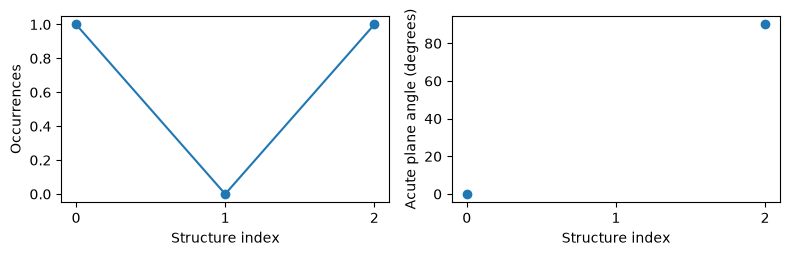

In [9]:
import matplotlib.pyplot as plt

counts = [analysis.query(structure_indices=frame).n_interactions for frame in range(3)]
fig, axes = plt.subplots(1, 2, figsize=(8, 2.6))
axes[0].plot(range(3), counts, 'o-')
axes[0].set(xlabel='Structure index', ylabel='Occurrences', xticks=range(3))
axes[1].plot(analysis.occurrence_structures, np.rad2deg(analysis.measurements['plane_angle']), 'o')
axes[1].set(xlabel='Structure index', ylabel='Acute plane angle (degrees)', xticks=range(3))
fig.tight_layout()
assert counts == [1, 0, 1]

## Declaring biological chemical motifs

Phenylalanine and tyrosine side chains contain phenyl and phenol motifs. Here explicit
SMILES fragments represent those chemical groups, while assigned coordinates provide a
controlled contact. This is a chemical analogue, not a complete protein simulation.
Unknown aromatic flags in a real protein require chemical preparation before calculation.

In [10]:
topology_A = msm.convert('smiles:c1ccccc1.c1ccccc1O', to_form='molsysmt.Topology')
molsys_A = msm.convert(topology_A, to_form='molsysmt.MolSys')
molsys_A.structures.append(coordinates=puw.quantity(
    [np.concatenate((ring, ring + [0, 0, .35], [[.28, 0, .35]]))], 'nm'))
biological = calculate(source=molsys_A)
assert biological.n_interactions == 1
assert biological.query(atom_indices=[12]).n_interactions == 0
print(biological.relation(0))

{'interaction_type': 'pi_pi', 'participants': [{'role': 'ring_a', 'atom_indices': array([0, 1, 2, 3, 4, 5])}, {'role': 'ring_b', 'atom_indices': array([ 6,  7,  8,  9, 10, 11])}]}


## Choosing the chemical state

Explicit state indices and the reference state resolve the same stored chemistry here.
The detector prepares one state for the entire request. With chemical_state='structure',
all requested frames must have one known, identical state assignment.

In [11]:
explicit_state = calculate(chemical_state=0)
print(explicit_state.parameters['chemical_state_index'])
np.testing.assert_array_equal(explicit_state.occurrence_structures, analysis.occurrence_structures)

0


## Preserving periodic geometry

Images are added to ring_b: observed coordinates equal raw coordinates plus
image_vector @ box, with box vectors as rows. Ring_a uses the zero vector.
Each compound ring must already be whole in its anchor-relative image. Split
participants raise an error rather than receiving an inferred reconstruction.

In [12]:
molsys_B = msm.extract(molsys, structure_indices=[0])
box = np.eye(3) * 2
periodic_coordinates = coordinates[:1].copy()
periodic_coordinates[:, 6:] += box[0]
msm.set(molsys_B, coordinates=puw.quantity(periodic_coordinates, 'nm'), box=puw.quantity([box], 'nm'))
periodic = calculate(source=molsys_B, pbc=True)
print(periodic.image_vectors.tolist())
assert periodic.image_vectors.tolist() == [[0, 0, 0], [-1, 0, 0]]
observed = [periodic_coordinates[0, part['atom_indices']] + shift @ box
            for part, shift in zip(periodic.relation(0)['participants'], periodic.image_vectors)]
assert np.isclose(np.linalg.norm(observed[1].mean(axis=0) - observed[0].mean(axis=0)), .35)

[[0, 0, 0], [-1, 0, 0]]


## Returning and attaching analyses

The default is a sparse Interactions object. Its typed dictionary preserves measures,
units, evidence and the software version used at calculation time. Attachment is
explicit and named; independent files require a declared index correspondence.

In [13]:
dictionary = calculate(output_type='molsysmt.InteractionsDict')
restored = msm.convert(dictionary, to_form='molsysmt.Interactions')
molsys.interactions = {**molsys.interactions, 'aromatic_contacts': analysis}
assert restored.n_interactions == analysis.n_interactions
print(molsys.interactions.keys(), restored.software)

dict_keys(['aromatic_contacts']) {'molsysmt': '0.22.4+24.g42b487869', 'networkx': '3.7'}


## Processing bounded coordinate blocks

Native and H5MSM sources supply projected blocks. Other supported forms use their
coordinate getters eagerly unless they declare real streaming support. The complete
sparse result remains in RAM. Extremely large numbers of accepted observations can
exceed its budget even when coordinate blocks are small. Auto chooses a bounded route;
force requires streaming and off must fit selected eager work. Ring-basis size is
bounded by max_cyclic_block_size, which is not a total-RSS guarantee.

In [14]:
with msm.configure.context(chunk_size=1):
    chunked = calculate(heavy_mode='force')
    eager = calculate(heavy_mode='off')
np.testing.assert_array_equal(chunked.occurrence_structures, eager.occurrence_structures)
np.testing.assert_allclose(chunked.measurements['distance'], eager.measurements['distance'])
print(chunked.execution_records[0]['details']['execution'], chunked.execution_records[0]['details']['execution_chunks'])

chunked 3


## Comparing attributed profiles

Choose `method="plane_angle_intersection", profile="smarts_5_6"` for its original 5/6-member SMARTS and FaceToFace/EdgeToFace core.
`method="centroid_angle_offset", profile="three_atom_plane"` applies Mol* triangle-normal, centroid-distance and either-offset
criteria to our declared aromatic basis. `method="plane_angle_intersection", profile="aromatic_cycles"` applies its ordered
centroid-edge normals and plane-intersection criteria to that basis. Their defaults
are independent of the custom four-cutoff proposal. No full Mol* valence-model
feature discovery or fingerprint refinement is claimed.

ProLIF/MDTraj edge criteria project ring_a's centroid on the planes' intersection:
reversing ring roles can change the decision. Canonical source membership fixes roles;
we do not symmetrize it. Reference comparisons use no added ULP tolerance. Float64
MolSysMT and float32 MDTraj can differ exactly at thresholds. Our coherent whole-ring
MIC extension also differs from MDTraj's mixture of wrapped distance/raw angles.
The following loop retains the software selectors as compatibility checks.


In [15]:
known_profiles = {method: msm.interactions.pi_pi.get_pi_pi_interactions(molsys, method=method, pbc=False)
                  for method in ('prolif', 'molstar_geometry', 'mdtraj_geometry')}
for method, result in known_profiles.items():
    print(method, result.occurrence_structures.tolist(), result.parameters['method_reference']['software'])
    assert result.evaluated_structure_indices.tolist() == [0, 1, 2]
print(known_profiles['prolif'].measurements['intersection_distance'])

prolif [0, 2] ProLIF
molstar_geometry [0, 2] Mol*
mdtraj_geometry [0, 2] MDTraj
[nan  0.]


Persist this named analysis and calculate directly from an H5MSM source using
{ref}`Cookbook_Saving_pi_pi_interactions`.

:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Getting aromatic rings <Tutorial_Get_aromatic_rings>` — chemical participants,
  {func}`molsysmt.physchem.get_aromatic_rings`.
- {ref}`Getting least-squares planes <Tutorial_Get_least_squares_plane>` — independent
  geometry, {func}`molsysmt.structure.get_least_squares_plane`.
:::

## Retaining scientific attribution

The analysis records `method`, `profile`, `method_definition` and a compact
bibliography in `analysis.parameters['attribution']`. Bibliographic roles distinguish
the scientific criterion, reference implementation and software actually executed.
These records survive typed conversion and H5MSM 0.5 persistence. Loading the file
does not claim a new calculation. With optional Ackredit installed, completed
calculations also contribute to the caller's workflow session. No hooks, online DOI
lookup or journal are enabled by MolSysMT.
See {ref}`Methods and attribution <user-tools-interactions-attribution>` for the
canonical method/profile table, compatible aliases and optional reporting example.


In [16]:
print(analysis.parameters['method'], analysis.parameters['profile'])
print([(item['title'], item['roles']) for item in analysis.parameters['attribution']['items']])


centroid_angle_offset least_squares
[('MolSysMT', ['executed_software']), ('networkx', ['executed_software'])]
